# Dataset loading

The full training/validation dataset includes 516 melting temperatures of 12 sequences at mixtures of Monovalent (Mainly Tris and Potassium) and Divalent (Mainly Magnesium) ions.\
The salt concentrations vary from 0-125mM for Divalent cations, and from 1-1005mM for Monovalent cations. This typically covers all possible ranges of concentrations considered by experiments.\
Those 12 sequences cover 4 main length categories (15/20/25/30bp - 3 seq per length) and 3 main GC-categories (0.3/0.5/0.7 - 4 seq per GC).\
The testing set includes 39 melting temperature of completely different sequences within the same range of GC-content as the training set, but with multiple samples of duplex length outside the training distribution (Check the EDA notebook for more details).

In [30]:
# Loading the training/validation data and test data
import pandas as pd
import numpy as np
owc2008_table4 = pd.read_csv('../datasets/owc2008_table4_all516.csv') # Training and validation data
owc2008_table4.head(10)

,duplex_id,sequence_5to3,length_bp,monovalent_mM,Mg2+_mM,Tm_C
0,ODN1,TTCTACCTATGTGAT,15,1,0.5,43.3
1,ODN1,TTCTACCTATGTGAT,15,1,1.5,46.1
2,ODN1,TTCTACCTATGTGAT,15,1,3.0,47.8
3,ODN1,TTCTACCTATGTGAT,15,1,10.0,50.2
4,ODN1,TTCTACCTATGTGAT,15,1,20.0,50.4
5,ODN1,TTCTACCTATGTGAT,15,5,0.5,42.1
6,ODN1,TTCTACCTATGTGAT,15,5,1.5,45.6
7,ODN1,TTCTACCTATGTGAT,15,5,3.0,47.6
8,ODN1,TTCTACCTATGTGAT,15,5,10.0,49.5
9,ODN1,TTCTACCTATGTGAT,15,5,20.0,50.4


In [31]:
owc2008_tableS2 = pd.read_csv('../datasets/owc2008_tableS2_cleaned.csv') # Test data
owc2008_tableS2.drop(owc2008_tableS2.columns[[2,3]], axis=1).head(10)

,sequence_5to3,length_bp,Mg2+_mM,Tm_C
0,CTGACGACAAGACT,14,1.5,51.8
1,CTGACGACAAGACT,14,10.0,56.3
2,GTAACCGGCATGAA,14,20.0,57.0
3,GTAACCGGCATGAA,14,20.0,57.0
4,CGCTGCTCACCTGA,14,3.0,59.6
5,CGCTGCTCACCTGA,14,125.0,62.0
6,TCTCAATGGTGTTACG,16,1.5,51.8
7,TCTCAATGGTGTTACG,16,0.5,49.0
8,TCTCAAACACCACACG,16,3.0,57.7
9,TCTCAAACACCACACG,16,10.0,60.0


In [32]:
# Drop the duplex_id column since it is captured anyway through the sequence column
owc2008_table4.drop(columns=['duplex_id'], inplace=True)

# Add log-salt columns since we know from the literature that the relationship between salt and Tm is logarithmic
# To be used later on
owc2008_table4['log_monovalent_M'] = np.log(owc2008_table4['monovalent_mM']*1e-3 + 1e-5)  # Convert to M and add a 0.01 mM constant to avoid log(0)
owc2008_table4['log_Mg2+_M'] = np.log(owc2008_table4['Mg2+_mM']*1e-3 + 1e-5)  # Convert to M and add a 0.01 mM constant to avoid log(0)

# Do the same for the test data
owc2008_tableS2['log_monovalent_M'] = np.log(owc2008_tableS2['monovalent_mM']*1e-3 + 1e-5)  # Convert to M and add a 0.01 mM constant to avoid log(0)
owc2008_tableS2['log_Mg2+_M'] = np.log(owc2008_tableS2['Mg2+_mM']*1e-3 + 1e-5)  # Convert to M and add a 0.01 mM constant to avoid log(0)


owc2008_table4.head(10)

,sequence_5to3,length_bp,monovalent_mM,Mg2+_mM,Tm_C,log_monovalent_M,log_Mg2+_M
0,TTCTACCTATGTGAT,15,1,0.5,43.3,-6.897805,-7.581100
1,TTCTACCTATGTGAT,15,1,1.5,46.1,-6.897805,-6.495646
2,TTCTACCTATGTGAT,15,1,3.0,47.8,-6.897805,-5.805815
3,TTCTACCTATGTGAT,15,1,10.0,50.2,-6.897805,-4.604171
4,TTCTACCTATGTGAT,15,1,20.0,50.4,-6.897805,-3.911523
5,TTCTACCTATGTGAT,15,5,0.5,42.1,-5.296319,-7.581100
6,TTCTACCTATGTGAT,15,5,1.5,45.6,-5.296319,-6.495646
7,TTCTACCTATGTGAT,15,5,3.0,47.6,-5.296319,-5.805815
8,TTCTACCTATGTGAT,15,5,10.0,49.5,-5.296319,-4.604171
9,TTCTACCTATGTGAT,15,5,20.0,50.4,-5.296319,-3.911523


# Models and Metrics

As introduced in the EDA notebook, our goal is two fold:
1. We would like to acheieve high predicition accuracy (Low MAE) with a limited number of data points (516 melting temperature - 12 Main sequences).
2. We *hope* to have a single and interpretable model that captures the most biophysically relevant dependencies of the melting temperature (Low complexity and number of features).

To handle the first point, we will be using **Mean Absolute Error (MAE)** as our metric since it was the main metric used by the prior studies (Owc-2008).\
Also, given the limited number of data points and the target accuracy, I think it will be best to use non-linear models that handle such scenarios right away. **In particular, we will compare LinearRegression (LR), GeneralizedAdditiveModels (GAM), and DecesionTreeRegressor (DT).** \
Given the EDA we did in the EDA notebook, non-linear dependencies and salt interactions seem unavoidable, so these models would be our first approach in capturing such complexity and confirm such behavior. However, the non-linearity was challenged in other studies (Unzip-2010 and Unzip-2017) which suggested a linear model with a different set of features.

To investigate the second point, we will compare the different models on multiple variations of the dataset each with **a different set of features (Features Engineering)** to find *the minimal set* of features needed to generalize to unseen data. This will help us narrow down the most important features and potential salt-feature interactions.\
The point of intpretability/simplicity is a challenge, but **LR and GAM** should make it possible to tackle such challenges.\
**DT** would be the next more complex model that captures more non-linear effects, but it is also more likely to overfit. We consider it as well for completeness.

# Features engineering

We will compare different sets of features to select the most important ones.\
**The best performing model should be the one performing the best in terms of the number of features and the validation-MAE score (Lower=Better, for both).**

As explored in the EDA notebook and as seen in literature, the melting temperature is highly dependent on GC-content, Duplex Length, and Log[Salt], but it will be nice to see how good a model that has other features engineered is doing.\
The main motivation of the features used should be its ability to generalize to unseen sequences (beyond those 12 sequences), so we will try to extract important features of those 12 sequences at hand that can capture their primary properties, yet sharable by similar sequences and easier to generalize.\
In particular, the duplex length will need to be present in all sets of features since it is *a signature property*; however, the GC-content for example can be captured in different ways.

To this end, we will compare the models performance on three sets of features:
1. *The typical set of features - our baseline model*: Similar to the ones usually found in literature, we add the GC-content feature. 
2. *The naive set of features*: This will just include the fraction of each nucleotide (A,T,C,G). 
3. *The modern set of features*: This will use the fraction of the ten different dinucleotide steps (AA/TT, GC/CG, AC/GT, ...) to capture the suggestion of the more recent papers (Unzip-2010 and Unzip-2017). For simplicity, we will ignore the two terminal contributions (Edge effects) for now (Unzip-2010).

Generally:
1. They all include the duplex length, as highlighted before.
2. They all include monovalent and divalent salt concentrations in mM.\
We will **MAINLY USE** Log-transformation of the salt concentration in M is necessary, following literature trends.
3. For each set of features, we will have a Feature-Salt-interaction set.\
This will include Monovalent_mM-Feature and Divalent_mM-Feature, for each feature.

## 1.1 Typical set of features

In [33]:
salt_baseline_features = ['log_monovalent_M', 'log_Mg2+_M']
sequence_baseline_features = ['length_bp', 'GC_content']

typical_features_no_salt_interaction = salt_baseline_features + sequence_baseline_features

# Add length_bp and GC-content columns
owc2008_table4['length_bp'] = owc2008_table4['sequence_5to3'].apply(len)
owc2008_table4['GC_content'] = owc2008_table4['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0)

# Do the same thing for the test data
owc2008_tableS2['length_bp'] = owc2008_tableS2['sequence_5to3'].apply(len)
owc2008_tableS2['GC_content'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0)

owc2008_table4[typical_features_no_salt_interaction].head(10)

,log_monovalent_M,log_Mg2+_M,length_bp,GC_content
0,-6.897805,-7.581100,15,0.333333
1,-6.897805,-6.495646,15,0.333333
2,-6.897805,-5.805815,15,0.333333
3,-6.897805,-4.604171,15,0.333333
4,-6.897805,-3.911523,15,0.333333
5,-5.296319,-7.581100,15,0.333333
6,-5.296319,-6.495646,15,0.333333
7,-5.296319,-5.805815,15,0.333333
8,-5.296319,-4.604171,15,0.333333
9,-5.296319,-3.911523,15,0.333333


## 1.2 Typical set of features (with salt interactions)

In [34]:
typical_features_with_salt_interaction = typical_features_no_salt_interaction.copy() # To avoid modifying the original list

# Add salt interaction features to the DataFrame
for salt in salt_baseline_features:
    for feature in sequence_baseline_features:
        owc2008_table4[f'{salt}-{feature}'] = owc2008_table4[salt] * owc2008_table4[feature]
        # Similarly, we add the interaction features to the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[feature]
        typical_features_with_salt_interaction.append(f'{salt}-{feature}')

owc2008_table4[typical_features_with_salt_interaction].head(10)

,log_monovalent_M,log_Mg2+_M,length_bp,GC_content,log_monovalent_M-length_bp,log_monovalent_M-GC_content,log_Mg2+_M-length_bp,log_Mg2+_M-GC_content
0,-6.897805,-7.581100,15,0.333333,-103.467074,-2.299268,-113.716497,-2.527033
1,-6.897805,-6.495646,15,0.333333,-103.467074,-2.299268,-97.434684,-2.165215
2,-6.897805,-5.805815,15,0.333333,-103.467074,-2.299268,-87.087228,-1.935272
3,-6.897805,-4.604171,15,0.333333,-103.467074,-2.299268,-69.062560,-1.534724
4,-6.897805,-3.911523,15,0.333333,-103.467074,-2.299268,-58.672847,-1.303841
5,-5.296319,-7.581100,15,0.333333,-79.444790,-1.765440,-113.716497,-2.527033
6,-5.296319,-6.495646,15,0.333333,-79.444790,-1.765440,-97.434684,-2.165215
7,-5.296319,-5.805815,15,0.333333,-79.444790,-1.765440,-87.087228,-1.935272
8,-5.296319,-4.604171,15,0.333333,-79.444790,-1.765440,-69.062560,-1.534724
9,-5.296319,-3.911523,15,0.333333,-79.444790,-1.765440,-58.672847,-1.303841


## 2.1 Naive set of features

Given the constraint of *Sum(fractions)=1*, it is redundunt to simultanously have the four fractions, so we only keep three of them here.\
In particular, we drop the fraction of A or T and keep the fractions of G and C since (GC-content=f_C+f_G), so we are adding one new feature on top of the previous ones.

In [35]:
naive_baseline_features = ['f_A', 'f_G', 'f_C', 'length_bp']
naive_features_no_salt_interaction = naive_baseline_features + salt_baseline_features

# Add the counts of each nucleotide as features
for nucleotide in ['A', 'G', 'C']:
    owc2008_table4[f'f_{nucleotide}'] = owc2008_table4['sequence_5to3'].apply(lambda seq: seq.count(nucleotide)/len(seq) if len(seq) > 0 else 0)
    # Do the same thing for the test data
    owc2008_tableS2[f'f_{nucleotide}'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: seq.count(nucleotide)/len(seq) if len(seq) > 0 else 0)

owc2008_table4[naive_features_no_salt_interaction].head(10)

,f_A,f_G,f_C,length_bp,log_monovalent_M,log_Mg2+_M
0,0.2,0.133333,0.2,15,-6.897805,-7.581100
1,0.2,0.133333,0.2,15,-6.897805,-6.495646
2,0.2,0.133333,0.2,15,-6.897805,-5.805815
3,0.2,0.133333,0.2,15,-6.897805,-4.604171
4,0.2,0.133333,0.2,15,-6.897805,-3.911523
5,0.2,0.133333,0.2,15,-5.296319,-7.581100
6,0.2,0.133333,0.2,15,-5.296319,-6.495646
7,0.2,0.133333,0.2,15,-5.296319,-5.805815
8,0.2,0.133333,0.2,15,-5.296319,-4.604171
9,0.2,0.133333,0.2,15,-5.296319,-3.911523


## 2.2 Naive set of features (with salt interaction)

In [36]:
naive_features_with_salt_interaction = naive_features_no_salt_interaction.copy() 

for salt in salt_baseline_features:
    for feature in naive_baseline_features:
        owc2008_table4[f'{salt}-{feature}'] = owc2008_table4[salt] * owc2008_table4[f'{feature}']
        naive_features_with_salt_interaction.append(f'{salt}-{feature}')
        # Do the same thing for the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[f'{feature}']


owc2008_table4[naive_features_with_salt_interaction].head(10)

,f_A,f_G,f_C,length_bp,log_monovalent_M,log_Mg2+_M,log_monovalent_M-f_A,log_monovalent_M-f_G,log_monovalent_M-f_C,log_monovalent_M-length_bp,log_Mg2+_M-f_A,log_Mg2+_M-f_G,log_Mg2+_M-f_C,log_Mg2+_M-length_bp
0,0.2,0.133333,0.2,15,-6.897805,-7.581100,-1.379561,-0.919707,-1.379561,-103.467074,-1.516220,-1.010813,-1.516220,-113.716497
1,0.2,0.133333,0.2,15,-6.897805,-6.495646,-1.379561,-0.919707,-1.379561,-103.467074,-1.299129,-0.866086,-1.299129,-97.434684
2,0.2,0.133333,0.2,15,-6.897805,-5.805815,-1.379561,-0.919707,-1.379561,-103.467074,-1.161163,-0.774109,-1.161163,-87.087228
3,0.2,0.133333,0.2,15,-6.897805,-4.604171,-1.379561,-0.919707,-1.379561,-103.467074,-0.920834,-0.613889,-0.920834,-69.062560
4,0.2,0.133333,0.2,15,-6.897805,-3.911523,-1.379561,-0.919707,-1.379561,-103.467074,-0.782305,-0.521536,-0.782305,-58.672847
5,0.2,0.133333,0.2,15,-5.296319,-7.581100,-1.059264,-0.706176,-1.059264,-79.444790,-1.516220,-1.010813,-1.516220,-113.716497
6,0.2,0.133333,0.2,15,-5.296319,-6.495646,-1.059264,-0.706176,-1.059264,-79.444790,-1.299129,-0.866086,-1.299129,-97.434684
7,0.2,0.133333,0.2,15,-5.296319,-5.805815,-1.059264,-0.706176,-1.059264,-79.444790,-1.161163,-0.774109,-1.161163,-87.087228
8,0.2,0.133333,0.2,15,-5.296319,-4.604171,-1.059264,-0.706176,-1.059264,-79.444790,-0.920834,-0.613889,-0.920834,-69.062560
9,0.2,0.133333,0.2,15,-5.296319,-3.911523,-1.059264,-0.706176,-1.059264,-79.444790,-0.782305,-0.521536,-0.782305,-58.672847


## 3.1 Modern set of features

Out of the ten dinucleotide steps, eight are independent (SantaLucia-1998, Unzip-2017, and Volo-2018). Hence, we drop the extra two dinucleotide steps (GC/CG and TA/AT) to avoid colinearity.

In [37]:
# The ten dinucleotide with 2 terminal factors ('AA/TT', 'AT/TA', 'TA/AT', 'CA/GT', 'GT/CA', 'CT/GA', 'GA/CT', 'CG/GC', 'GC/CG', 'GG/CC', 'Terminal_A/T', 'Terminal_G/C') frequency features
dinucleotide_step = ['AA/TT', 'AT/TA', 'CA/GT', 'GT/CA', 'CT/GA', 'GA/CT', 'CG/GC', 'GG/CC']
terminal_step = ['Terminal_A/T', 'Terminal_G/C']
dinucleotide_steps = dinucleotide_step #+ terminal_step
dinucleotide_freq = [f'f_{dinucleotide}' for dinucleotide in dinucleotide_steps]

def calculate_dinucleotide_frequencies(seq):
    frequencies = {}

    canonical_map = {
        'AA': 'AA/TT', 
        'TT': 'AA/TT',

        'GG': 'GG/CC', 
        'CC': 'GG/CC',

        'AT': 'AT/TA',
        #'TA': 'AT/TA',

        'CA': 'CA/GT', 
        'TG': 'CA/GT',

        'GT': 'GT/CA', 
        'AC': 'GT/CA',

        'CT': 'CT/GA', 
        'AG': 'CT/GA',

        'GA': 'GA/CT', 
        'TC': 'GA/CT',

        'CG': 'CG/GC',
        #'GC': 'CG/GC',
    }

    # Generate dinucleotide pairs
    dinucleotide_pairs = [canonical_map.get(seq[i:i+2], None) for i in range(len(seq) - 1) if seq[i:i+2] in canonical_map]

    # Count the frequencies of each dinucleotide pair
    for pair in dinucleotide_pairs:
        frequencies[pair] = frequencies.get(pair, 0) + 1

    # Calculate terminal nucleotide frequencies (count A and T as Terminal_A/T, count G and C as Terminal_G/C)
    if len(seq) > 0:
        if seq[0] in ['A', 'T']:
            frequencies['Terminal_A/T'] = frequencies.get('Terminal_A/T', 0) + 1
        else:
            frequencies['Terminal_G/C'] = frequencies.get('Terminal_G/C', 0) + 1
        if seq[-1] in ['A', 'T']:
            frequencies['Terminal_A/T'] = frequencies.get('Terminal_A/T', 0) + 1
        else:
            frequencies['Terminal_G/C'] = frequencies.get('Terminal_G/C', 0) + 1 

    return frequencies


In [38]:
modern_baseline_features = ['length_bp']
modern_features_no_salt_interaction = ['length_bp'] + salt_baseline_features

# Add the dinucleotide frequency features 
for feature in dinucleotide_freq:
    owc2008_table4[f'{feature}'] = owc2008_table4['sequence_5to3'].apply(lambda seq: calculate_dinucleotide_frequencies(seq).get(feature[2:], 0)/len(seq) if len(seq) > 0 else 0)
    modern_features_no_salt_interaction.append(f'{feature}')
    modern_baseline_features.append(f'{feature}')
    # Do the same thing for the test data
    owc2008_tableS2[f'{feature}'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: calculate_dinucleotide_frequencies(seq).get(feature[2:], 0)/len(seq) if len(seq) > 0 else 0)

owc2008_table4[modern_features_no_salt_interaction].head(10)

,length_bp,log_monovalent_M,log_Mg2+_M,f_AA/TT,f_AT/TA,f_CA/GT,f_GT/CA,f_CT/GA,f_GA/CT,f_CG/GC,f_GG/CC
0,15,-6.897805,-7.581100,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
1,15,-6.897805,-6.495646,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
2,15,-6.897805,-5.805815,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
3,15,-6.897805,-4.604171,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
4,15,-6.897805,-3.911523,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
5,15,-5.296319,-7.581100,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
6,15,-5.296319,-6.495646,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
7,15,-5.296319,-5.805815,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
8,15,-5.296319,-4.604171,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
9,15,-5.296319,-3.911523,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667


## 3.2 Modern features (with salt interaction)

In [39]:
# Interaction features between salt concentration and dinucleotide frequencies (Ignoring terminal dinucleotide features for now since they are more complex to interpret and may not have as strong of an interaction with salt concentration as the internal dinucleotide frequencies)
modern_features_with_salt_interaction = modern_features_no_salt_interaction.copy() 
for salt in salt_baseline_features:
    for feature in modern_baseline_features:
        owc2008_table4[f'{salt}-{feature}'] = owc2008_table4[salt] * owc2008_table4[f'{feature}']
        modern_features_with_salt_interaction.append(f'{salt}-{feature}')
        # Do the same thing for the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[f'{feature}']

owc2008_table4[modern_features_with_salt_interaction].head(10)

,length_bp,log_monovalent_M,log_Mg2+_M,f_AA/TT,f_AT/TA,f_CA/GT,f_GT/CA,f_CT/GA,f_GA/CT,f_CG/GC,...,log_monovalent_M-f_GG/CC,log_Mg2+_M-length_bp,log_Mg2+_M-f_AA/TT,log_Mg2+_M-f_AT/TA,log_Mg2+_M-f_CA/GT,log_Mg2+_M-f_GT/CA,log_Mg2+_M-f_CT/GA,log_Mg2+_M-f_GA/CT,log_Mg2+_M-f_CG/GC,log_Mg2+_M-f_GG/CC
0,15,-6.897805,-7.581100,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.459854,-113.716497,-0.505407,-1.010813,-1.010813,-1.010813,-1.010813,-1.010813,-0.0,-0.505407
1,15,-6.897805,-6.495646,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.459854,-97.434684,-0.433043,-0.866086,-0.866086,-0.866086,-0.866086,-0.866086,-0.0,-0.433043
2,15,-6.897805,-5.805815,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.459854,-87.087228,-0.387054,-0.774109,-0.774109,-0.774109,-0.774109,-0.774109,-0.0,-0.387054
3,15,-6.897805,-4.604171,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.459854,-69.062560,-0.306945,-0.613889,-0.613889,-0.613889,-0.613889,-0.613889,-0.0,-0.306945
4,15,-6.897805,-3.911523,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.459854,-58.672847,-0.260768,-0.521536,-0.521536,-0.521536,-0.521536,-0.521536,-0.0,-0.260768
5,15,-5.296319,-7.581100,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.353088,-113.716497,-0.505407,-1.010813,-1.010813,-1.010813,-1.010813,-1.010813,-0.0,-0.505407
6,15,-5.296319,-6.495646,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.353088,-97.434684,-0.433043,-0.866086,-0.866086,-0.866086,-0.866086,-0.866086,-0.0,-0.433043
7,15,-5.296319,-5.805815,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.353088,-87.087228,-0.387054,-0.774109,-0.774109,-0.774109,-0.774109,-0.774109,-0.0,-0.387054
8,15,-5.296319,-4.604171,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.353088,-69.062560,-0.306945,-0.613889,-0.613889,-0.613889,-0.613889,-0.613889,-0.0,-0.306945
9,15,-5.296319,-3.911523,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,-0.353088,-58.672847,-0.260768,-0.521536,-0.521536,-0.521536,-0.521536,-0.521536,-0.0,-0.260768


# Models train/val for the different sets of features

*Note on cross-validation*:\
Since the goal is generalizing to unseen sequences, it makes sense to do a leave-one-sequence-out cross-validation. However, the limited dataset we have might lead to overfitting, so let's see how good this is.

In [40]:
# Showing the number of features in each feature set and order them in descending order
pd.set_option('display.max_colwidth', None)  # Unlimited column width
display(pd.DataFrame({
    'typical_no_salt': (len(typical_features_no_salt_interaction), typical_features_no_salt_interaction),
    'typical_with_salt': (len(typical_features_with_salt_interaction), typical_features_with_salt_interaction),
    'naive_no_salt': (len(naive_features_no_salt_interaction), naive_features_no_salt_interaction),
    'naive_with_salt': (len(naive_features_with_salt_interaction), naive_features_with_salt_interaction),
    'modern_no_salt': (len(modern_features_no_salt_interaction), modern_features_no_salt_interaction),
    'modern_with_salt': (len(modern_features_with_salt_interaction), modern_features_with_salt_interaction)
}, index=['Number of Features', 'full list of features']).T.sort_values(by='Number of Features', axis=0, ascending=True).T)


,typical_no_salt,naive_no_salt,typical_with_salt,modern_no_salt,naive_with_salt,modern_with_salt
Number of Features,4,6,8,11,14,29
full list of features,"[log_monovalent_M, log_Mg2+_M, length_bp, GC_content]","[f_A, f_G, f_C, length_bp, log_monovalent_M, log_Mg2+_M]","[log_monovalent_M, log_Mg2+_M, length_bp, GC_content, log_monovalent_M-length_bp, log_monovalent_M-GC_content, log_Mg2+_M-length_bp, log_Mg2+_M-GC_content]","[length_bp, log_monovalent_M, log_Mg2+_M, f_AA/TT, f_AT/TA, f_CA/GT, f_GT/CA, f_CT/GA, f_GA/CT, f_CG/GC, f_GG/CC]","[f_A, f_G, f_C, length_bp, log_monovalent_M, log_Mg2+_M, log_monovalent_M-f_A, log_monovalent_M-f_G, log_monovalent_M-f_C, log_monovalent_M-length_bp, log_Mg2+_M-f_A, log_Mg2+_M-f_G, log_Mg2+_M-f_C, log_Mg2+_M-length_bp]","[length_bp, log_monovalent_M, log_Mg2+_M, f_AA/TT, f_AT/TA, f_CA/GT, f_GT/CA, f_CT/GA, f_GA/CT, f_CG/GC, f_GG/CC, log_monovalent_M-length_bp, log_monovalent_M-f_AA/TT, log_monovalent_M-f_AT/TA, log_monovalent_M-f_CA/GT, log_monovalent_M-f_GT/CA, log_monovalent_M-f_CT/GA, log_monovalent_M-f_GA/CT, log_monovalent_M-f_CG/GC, log_monovalent_M-f_GG/CC, log_Mg2+_M-length_bp, log_Mg2+_M-f_AA/TT, log_Mg2+_M-f_AT/TA, log_Mg2+_M-f_CA/GT, log_Mg2+_M-f_GT/CA, log_Mg2+_M-f_CT/GA, log_Mg2+_M-f_GA/CT, log_Mg2+_M-f_CG/GC, log_Mg2+_M-f_GG/CC]"


## Cross-Validation setup
Given that the goal is to be able to generalize to unseen sequences, we do a leave-one-sequence-out cross-validation (12-fold).

In [41]:
#from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Hacky solution to a dependency problem for pyGAM https://github.com/dswah/pyGAM/issues/357 
import scipy.sparse

def to_array(self):
    return self.toarray()

scipy.sparse.spmatrix.A = property(to_array)

# Generalized Additive Model (GAM):
# LinearGAM fits y ≈ sum_j f_j(x_j), where each f_j is a smooth curve.
from pygam import LinearGAM, s


# Zip feature sets with their corresponding hyperparameter grids
all_features = {
    'Typical': typical_features_no_salt_interaction,
    'Typical with salt interaction': typical_features_with_salt_interaction,
    'Naive': naive_features_no_salt_interaction,
    'Naive with salt interaction': naive_features_with_salt_interaction,
    'Modern': modern_features_no_salt_interaction,
    'Modern with salt interaction': modern_features_with_salt_interaction,

}

# No inner CV for hyperparameter tuning—just use fixed-default hyperparameters

models_names = ['Linear Regression', 'Generalized Additive Model', 'Decision Tree']
splits_names = ['Training', 'Validation']

In [42]:
# ============================================================================
# LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - By Sequence
# ============================================================================

print("\n" + "=" * 100)
print("LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - By Sequence")
print("=" * 100)
print(f"CV: Leave-one-sequence-out (tests generalization to new sequences)")

loso_fold_results = {
    feature_set_name: {
        model_name: {
            split_name: [] for split_name in splits_names
        } for model_name in models_names
    } for feature_set_name in all_features.keys()
}


unique_sequences = owc2008_table4['sequence_5to3'].unique()
fold_num = 1

for left_out_seq in unique_sequences:
    # Train on all sequences EXCEPT left_out_seq
    train_idx = owc2008_table4['sequence_5to3'] != left_out_seq
    val_idx = owc2008_table4['sequence_5to3'] == left_out_seq
    
    X_train = owc2008_table4[train_idx]
    X_val = owc2008_table4[val_idx]
    y_train = X_train['Tm_C']
    y_val = X_val['Tm_C']
    
    train_seqs = X_train['sequence_5to3'].nunique()
    train_count = len(X_train)
    val_count = len(X_val)

    for feature_set_name, feature_info in all_features.items():
        feature_set = feature_info
        feature_set_length = len(feature_set)

        # Linear Regression - no hyperparameters to tune
        lr = LinearRegression()
        lr.fit(X_train[feature_set], y_train)

        lr_mae_train = mean_absolute_error(y_train, lr.predict(X_train[feature_set]))
        lr_mae_val = mean_absolute_error(y_val, lr.predict(X_val[feature_set]))

        loso_fold_results[feature_set_name]['Linear Regression']['Training'].append((lr, lr_mae_train))
        loso_fold_results[feature_set_name]['Linear Regression']['Validation'].append((lr, lr_mae_val))


        # Generalized Additive Model - fixed hyperparameters
        # Num splines = number of features
        gam = LinearGAM(n_splines=feature_set_length)
        gam.fit(X_train[feature_set], y_train)

        gam_mae_train = mean_absolute_error(y_train, gam.predict(X_train[feature_set]))
        gam_mae_val = mean_absolute_error(y_val, gam.predict(X_val[feature_set]))

        loso_fold_results[feature_set_name]['Generalized Additive Model']['Training'].append((gam, gam_mae_train))
        loso_fold_results[feature_set_name]['Generalized Additive Model']['Validation'].append((gam, gam_mae_val))


        # Decision Tree - fixed hyperparameters
        dt = DecisionTreeRegressor(random_state=614)
        dt.fit(X_train[feature_set], y_train)
        
        dt_mae_train = mean_absolute_error(y_train, dt.predict(X_train[feature_set]))
        dt_mae_val = mean_absolute_error(y_val, dt.predict(X_val[feature_set]))
        
        loso_fold_results[feature_set_name]['Decision Tree']['Training'].append((dt, dt_mae_train))
        loso_fold_results[feature_set_name]['Decision Tree']['Validation'].append((dt, dt_mae_val))
        
    
    print(f"Fold {fold_num}/{len(unique_sequences)} | Left-out: {left_out_seq} | Train: {train_seqs} seqs ({train_count} samples) | Val: {val_count} samples")
    fold_num += 1

print("\n✓ LOSO CV Complete\n")


LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - By Sequence
CV: Leave-one-sequence-out (tests generalization to new sequences)
Fold 1/12 | Left-out: TTCTACCTATGTGAT | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 2/12 | Left-out: GCAGTGGATGTGAGA | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 3/12 | Left-out: CAGCCTCGTCGCAGC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 4/12 | Left-out: TGATTCTACCTATGTGATTT | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 5/12 | Left-out: AGCTGCAGTGGATGTGAGAA | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 6/12 | Left-out: CAGCCTCGTTCGCACAGCCC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 7/12 | Left-out: GTTCTATACTCTTGAAGTTGATTAC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 8/12 | Left-out: CTGGTCTGGATCTGAGAACTTCAGG | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 9/12 | Left-out: CAGTGGGCTCCTGGGCGTGCTGGTC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 10/12 | Left-out: CTTAAGATATGAGAACTTCA

In [43]:
# Compute summary statistics
print("\n" + "=" * 100)
print("SUMMARY STATISTICS - LOSO CV")
print("=" * 100 + "\n")

print("LEAVE-ONE-SEQUENCE-OUT CV Results:")

loso_summary = {}
for feature_set_name in all_features.keys():
    for model_name in models_names:
        for split_name in splits_names:
            mae_values = []
            for fold in range(len(unique_sequences)):
                model, mae = loso_fold_results[feature_set_name][model_name][split_name][fold]
                mae_values.append(mae)
            mean_mae = np.mean(mae_values)
            std_mae = np.std(mae_values)
            loso_summary.setdefault(feature_set_name+f' ({len(all_features[feature_set_name])})', {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

loso_df = pd.DataFrame(loso_summary).T
display(loso_df)


SUMMARY STATISTICS - LOSO CV

LEAVE-ONE-SEQUENCE-OUT CV Results:


,Linear Regression (Training),Linear Regression (Validation),Generalized Additive Model (Training),Generalized Additive Model (Validation),Decision Tree (Training),Decision Tree (Validation)
Typical (4),2.2737 ± 0.0585,2.6031 ± 0.7670,1.8386 ± 0.0286,2.1006 ± 0.5553,0.0000 ± 0.0000,5.9529 ± 1.5767
Typical with salt interaction (8),2.2411 ± 0.0595,2.5759 ± 0.7823,1.1668 ± 0.0114,1.3873 ± 0.2538,0.0000 ± 0.0000,6.8421 ± 1.6494
Naive (6),2.2377 ± 0.0676,3.1987 ± 1.0318,1.2537 ± 0.0085,1.8090 ± 0.5289,0.0000 ± 0.0000,8.6417 ± 6.0565
Naive with salt interaction (14),2.2027 ± 0.0651,3.1869 ± 1.0467,1.0787 ± 0.0073,1.7068 ± 0.6383,0.0000 ± 0.0000,7.5880 ± 5.7308
Modern (11),1.8842 ± 0.0585,5.6748 ± 2.6736,1.1926 ± 0.0113,5.4334 ± 2.8777,0.0000 ± 0.0000,9.0496 ± 8.0469
Modern with salt interaction (29),1.8405 ± 0.0493,5.6574 ± 2.6764,1.1304 ± 0.0098,7.9073 ± 3.9972,0.0000 ± 0.0000,8.2870 ± 7.2843


## Notes on the models performance and results
***Based on the comparison between training/validation MAE results***:\
There seems to be a train/val gap, especially for DT, which is a clear sign of overfitting using this more complex model.\
Similar pattern is seen with more complex features, particularly, the Modern set of features.\
*Hence, DT and Modern features set are excluded from comparison.*


***Based on the MAE on the validation set***:
1. *GAM is typically outperforming LR*.
This shows the non-linear nature of the salt dependency.
2. *The Typical set of features with salt interactions* seems to be doing the best overall, so we use it as our best set of features.
This agrees with literature and it is the least number of features encoding salt interactions, compared to the Naive one. 
3. It would have been nice to see the Modern set of features with LR competing with other models, as literature suggested, but the number of features involved in it seems too high given the limited number of data points in our case. It remain a possibility for future explorations.
4. Log-transformation of salt concentrations did not provide signficant improvement (results not shown). GAM is likely capturing such nonlinearity anyway.

***Best Model selection:***\
Given this discussion and that our target is low MAE with low complexity and interpretability with physical grounding, it is reasonable to choose **GAM with the Typical set of features** as the best model for the coming analysis.

In [44]:
# Retraining the best model on the full training data
our_feature_set = 'Typical with salt interaction'
best_model_name = 'Generalized Additive Model'

our_model = LinearGAM(n_splines=len(all_features[our_feature_set])).fit(owc2008_table4[all_features[our_feature_set]], owc2008_table4['Tm_C'])

## Best model analysis

In [45]:
our_model.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     29.7005
Link Function:                     IdentityLink Log Likelihood:                                  -977.3455
Number of Samples:                          516 AIC:                                             2016.0919
                                                AICc:                                             2020.111
                                                GCV:                                                3.0544
                                                Scale:                                              1.6552
                                                Pseudo R-Squared:                                     0.97
Feature Function                  Lam

C:\Users\ayman\AppData\Local\Temp\ipykernel_39088\3078057632.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  our_model.summary()


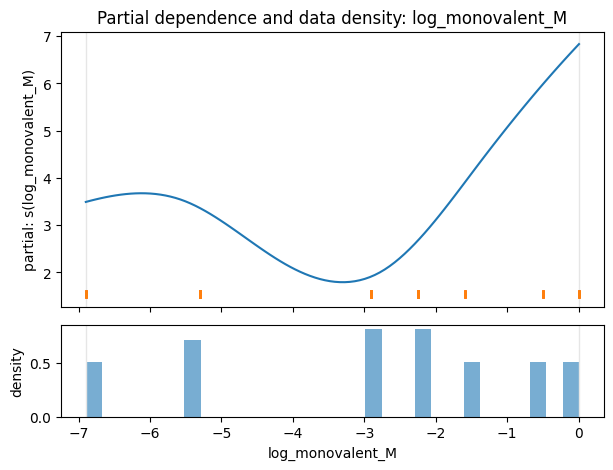

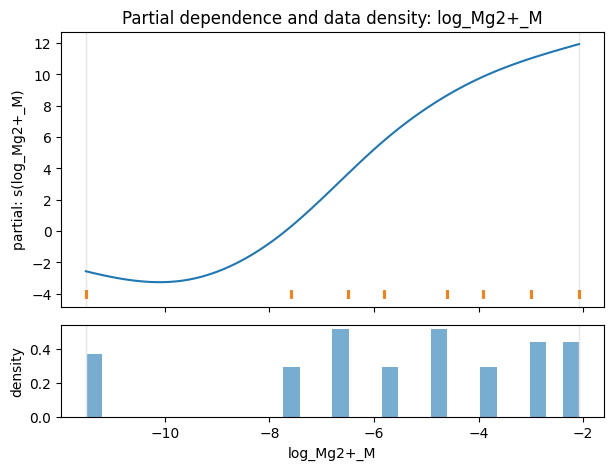

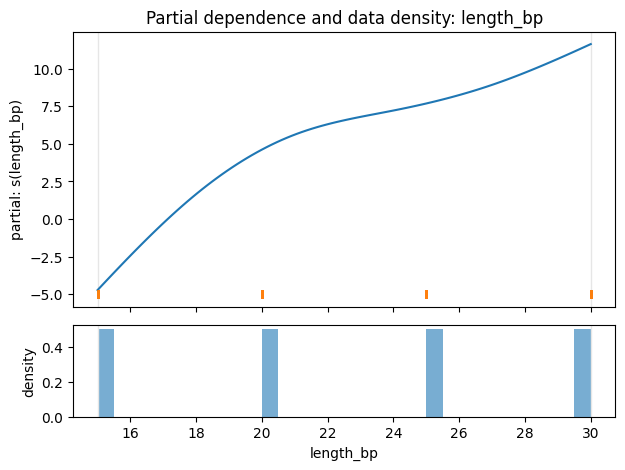

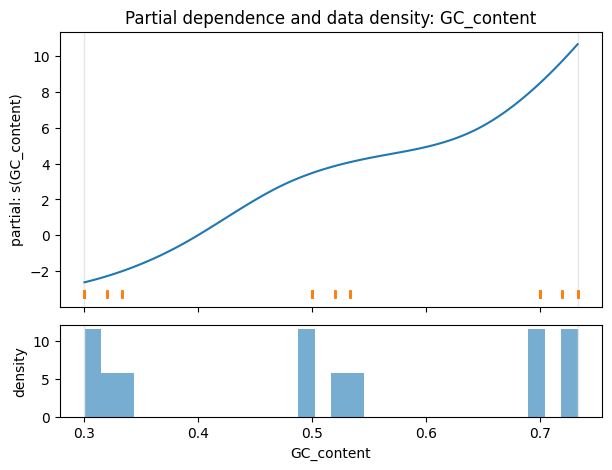

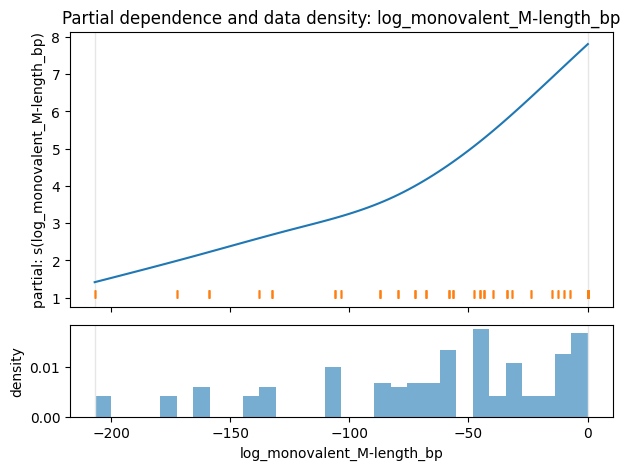

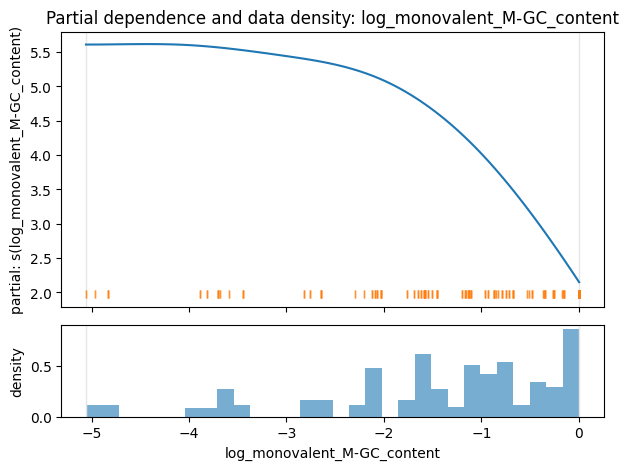

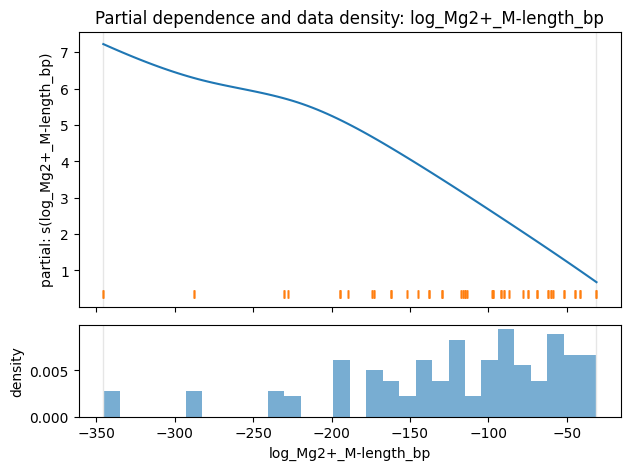

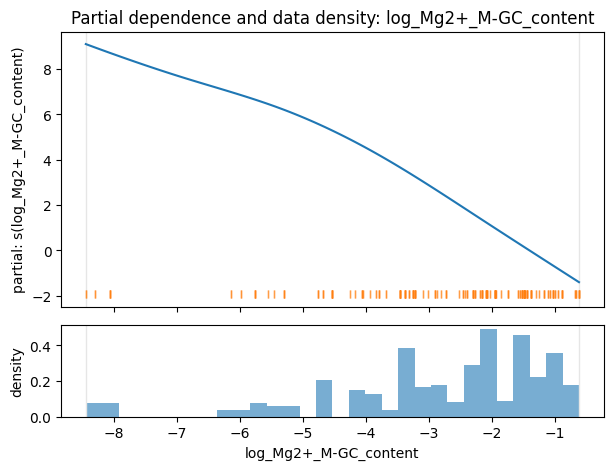

In [ ]:
# Making partial dependence plots for the features in our chosen model to visualize the relationships between the features and Tm

import numpy as np
import matplotlib.pyplot as plt

feature_indices = {name: i for i, name in enumerate(all_features[our_feature_set])}


for i, term in enumerate(our_model.terms):
    if term.isintercept:
        continue

    feat = all_features[our_feature_set][i]
    x_train = owc2008_table4[all_features[our_feature_set]][feat].to_numpy()

    # grid and partial dependence for this term
    XX = our_model.generate_X_grid(term=i)
    # column index of this feature in the grid (defensive in case of reordering)
    j = feature_indices[feat]
    x_grid = XX[:, j]
    pd_vals = our_model.partial_dependence(term=i, X=XX)

    # figure with stacked axes: partial dependence on top, histogram below
    fig, (ax, ax_hist) = plt.subplots(
        2, 1, figsize=(7, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.1}
    )

    # Partial dependence
    ax.plot(x_grid, pd_vals)
    ax.set_ylabel(f"partial: s({feat})")
    ax.set_title(f"Partial dependence and data density: {feat}")
    # optional: rug to show sample locations
    ax.plot(x_train, np.full_like(x_train, ax.get_ylim()[0]),
            "|", markersize=6, alpha=0.3)

    # Histogram of the feature (density-scaled)
    ax_hist.hist(x_train, bins=30, density=True, alpha=0.6)
    ax_hist.set_ylabel("density")
    ax_hist.set_xlabel(feat)

    # visually mark extrapolation beyond training range
    xmin, xmax = np.min(x_train), np.max(x_train)
    ax.axvspan(x_grid.min(), xmin, color="0.9")
    ax.axvspan(xmax, x_grid.max(), color="0.9")
    ax_hist.axvspan(x_grid.min(), xmin, color="0.9")
    ax_hist.axvspan(xmax, x_grid.max(), color="0.9")


    #plt.savefig(f'partial_dependence_{feat}.png', bbox_inches='tight')
    plt.show()

# Testing and comparing to the models Owc-2008

We evalaute the best performing models from the different CV strategies on the test set in order to pick the best overall model.

We also compare the performance of those models to the "model" developed in Owc-2008, which involves the decision tree of their Figure 9

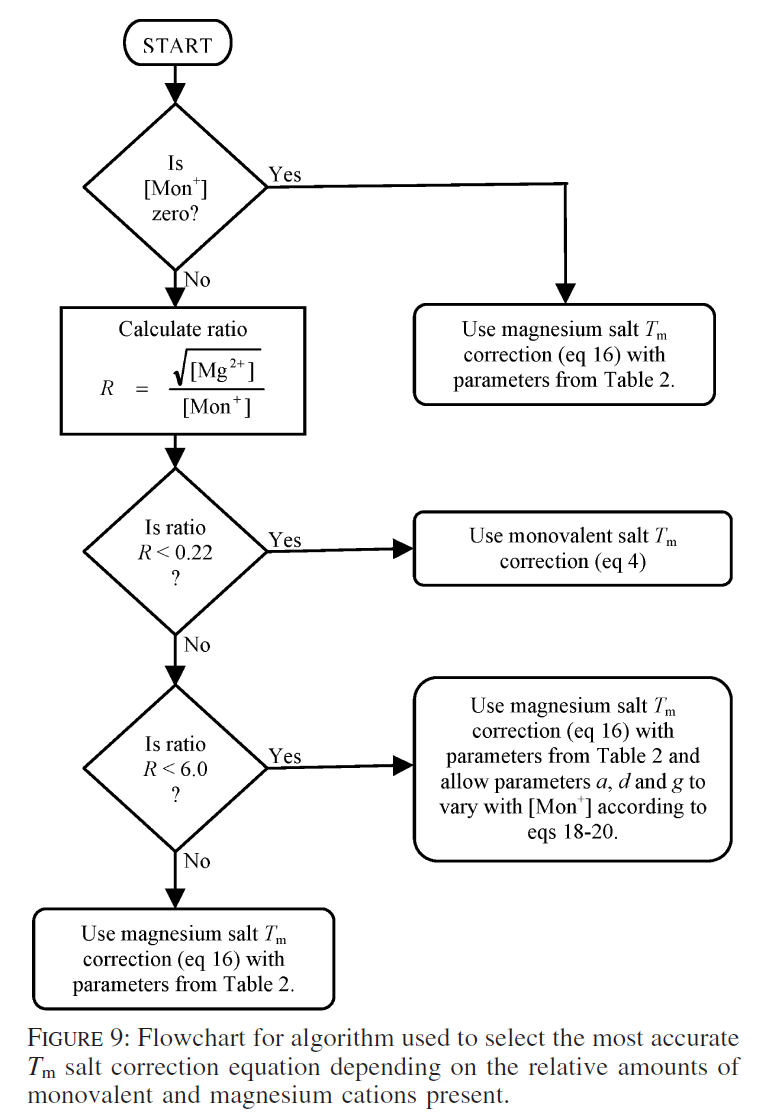

where the equations mentioned (Eq.4 and Eq.16) are the ones we gave in the EDA notebook.\
The complete function implementing this tree is given below (Thanks Claude!).\
We will use their complex function to compare performance with our developed models. 

**Things to keep in mind regarding the training and testing datasets**
1. Data in Table 4 was similarly used to train and develop their "model", so it is a fair comparison to use it here as well.
2. We do not compare the whole dataset in Table S2 since some of the data was obtained at different DNA concentrations, check EDA notebook for details. To this end, we have to evaluate their "model" again on this subset of the dataset of Table S2.

In [47]:
import math

def predict_tm_magnesium(tm_1M_Na, Nbp, fGC, Mg_total, Mon_total, dNTP_total=0.0):
    """
    Predict melting temperature (Tm) in buffers containing Mg2+ and monovalent ions.
    
    Based on Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
    Algorithm from Figure 9.

    Parameters
    ----------
    tm_1M_Na   : float  – reference Tm in 1 M Na+ buffer (Celsius)
    Nbp        : int    – number of base pairs
    fGC        : float  – fraction of G·C base pairs (0 to 1)
    Mg_total   : float  – total [Mg2+] in mol/L
    Mon_total  : float  – total monovalent ion concentration [Mon+] in mol/L
                          (sum of [K+] + [Na+] + [Tris+], where [Tris+] ≈ half of [Tris])
    dNTP_total : float  – total dNTP concentration in mol/L (default 0)
                          Free [Mg2+] = Mg_total - dNTP_total (if positive)

    Returns
    -------
    float : predicted Tm in Celsius
    """

    # --- Parameters from Table 2 (constant values) ---
    a0 = 3.92e-5
    b  = -9.11e-6
    c  = 6.26e-5
    d0 = 1.42e-5
    e  = -4.82e-4
    f  = 5.25e-4
    g0 = 8.31e-5

    # Reference Tm in Kelvin
    tm_ref_K = tm_1M_Na + 273.15

    # Compute free [Mg2+] accounting for dNTP chelation
    if dNTP_total > 0:
        free_Mg = Mg_total - dNTP_total
        if free_Mg < 0:
            # Use association constant approach (Ka ~ 3e4 L/mol) when dNTP >= Mg
            Ka = 3e4
            # Solve quadratic: Ka*[Mg]^2 + (Ka*(dNTP-Mg_total)+1)*[Mg] - Mg_total = 0
            A_coef = Ka
            B_coef = Ka * (dNTP_total - Mg_total) + 1
            C_coef = -Mg_total
            discriminant = B_coef**2 - 4 * A_coef * C_coef
            free_Mg = (-B_coef + math.sqrt(discriminant)) / (2 * A_coef)
    else:
        free_Mg = Mg_total

    # --- Figure 9 algorithm: select correction based on R ---

    # Branch 1: no monovalent ions present → use Eq. 16 with Table 2 params
    if Mon_total == 0:
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a0, b, c, d0, e, f, g0)
        return _inv_to_celsius(inv_tm)

    R = math.sqrt(free_Mg) / Mon_total  # units: M^(-1/2)

    # Branch 2: R < 0.22 → monovalent ions dominant, use Eq. 4
    if R < 0.22:
        inv_tm = _eq4(tm_ref_K, Mon_total, fGC)
        return _inv_to_celsius(inv_tm)

    # Branch 3: 0.22 <= R < 6.0 → mixed regime, Eq. 16 with a, d, g varying (Eqs. 18-20)
    elif R < 6.0:
        a = a0 * (0.843 - 0.352 * math.sqrt(Mon_total) * math.log(Mon_total))
        d = d0 * (1.279 - 4.03e-3 * math.log(Mon_total)
                        - 8.03e-3 * (math.log(Mon_total))**2)
        g = g0 * (0.486 - 0.258 * math.log(Mon_total)
                        + 5.25e-3 * (math.log(Mon_total))**3)
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a, b, c, d, e, f, g)
        return _inv_to_celsius(inv_tm)

    # Branch 4: R >= 6.0 → Mg2+ dominant, Eq. 16 with constant Table 2 params
    else:
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a0, b, c, d0, e, f, g0)
        return _inv_to_celsius(inv_tm)


def _eq16(tm_ref_K, Mg, fGC, Nbp, a, b, c, d, e, f, g):
    """Equation 16: Tm magnesium correction (returns 1/Tm in K^-1)."""
    ln_Mg = math.log(Mg)
    inv_tm = (1.0 / tm_ref_K
              + a
              + b * ln_Mg
              + fGC * (c + d * ln_Mg)
              + (1.0 / (2 * (Nbp - 1))) * (e + f * ln_Mg + g * ln_Mg**2))
    return inv_tm


def _eq4(tm_ref_K, Mon, fGC):
    """Equation 4: monovalent ion Tm correction (returns 1/Tm in K^-1)."""
    ln_Mon = math.log(Mon)
    inv_tm = (1.0 / tm_ref_K
              + (4.29 * fGC - 3.95) * 1e-5 * ln_Mon
              + 9.40e-6 * ln_Mon**2)
    return inv_tm


def _inv_to_celsius(inv_tm_K):
    """Convert 1/Tm (K^-1) to Tm in Celsius."""
    return (1.0 / inv_tm_K) - 273.15


# # --- Example from the paper (page 5348) ---
# if __name__ == "__main__":
#     # 20-bp duplex, fGC = 0.6, 1.5 mM Mg2+, 10 mM Tris-HCl
#     # [Tris+] ≈ 5 mM (half of 10 mM Tris is protonated at pH 8.3)
#     tm_ref   = 76.3          # Tm in 1 M Na+ (°C)
#     Nbp      = 20
#     fGC      = 0.600
#     Mg       = 0.0015        # 1.5 mM
#     Mon      = 0.005         # ~5 mM Tris+
#     dNTP     = 0.0

#     result = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg, Mon, dNTP)
#     print(f"Predicted Tm: {result:.1f} °C  (paper reports 67.9 °C, measured 68.5 °C)")




## 
# Tm_C at monovalent_mM = 1005 mM and Mg2+_mM = 0 mM is used as the reference Tm in 1 M Na+ for all sequences since it is the closest condition to 1 M Na+ in our dataset and it is the only condition in our dataset that has zero Mg2+ concentration, which is required for the reference Tm in 1 M Na+ according to the algorithm from Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
# Copied directly from the paper Table 4 (not part of the training data)
# reference_tm ={'TTCTACCTATGTGAT': np.float64(53.2),
#  'GCAGTGGATGTGAGA': np.float64(62.4),
#  'CAGCCTCGTCGCAGC': np.float64(70.6),
#  'TGATTCTACCTATGTGATTT': np.float64(63.2),
#  'AGCTGCAGTGGATGTGAGAA': np.float64(72.3),
#  'CAGCCTCGTTCGCACAGCCC': np.float64(78.4),
#  'GTTCTATACTCTTGAAGTTGATTAC': np.float64(68.0),
#  'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.8),
#  'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
#  'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(72.4),
#  'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.1),
#  'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.7)}
# This gives MAE=0.6C.

# Tm_C at monovalent_mM = 1.02 M is used as the reference Tm in 1 M Na+ for all sequences since it looks like that is what they did in the analysis shown in table 5 according to the main text of Owc-2008.
# Copied directly from the paper Table 2 of Owc-2004 (not part of the training data)
# reference_tm ={'TTCTACCTATGTGAT': np.float64(53.7),
#  'GCAGTGGATGTGAGA': np.float64(62.3),
#  'CAGCCTCGTCGCAGC': np.float64(72.0),
#  'TGATTCTACCTATGTGATTT': np.float64(64.4),
#  'AGCTGCAGTGGATGTGAGAA': np.float64(73.1),
#  'CAGCCTCGTTCGCACAGCCC': np.float64(78.1),
#  'GTTCTATACTCTTGAAGTTGATTAC': np.float64(67.7),
#  'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.6),
#  'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
#  'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(71.8),
#  'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.6),
#  'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.4)}
# # This given MAE=0.8C as they report in table 5 of Owc-2008.

# # Evaluate the magnesium correction model on the training data using the reference Tm values for each sequence and the corresponding salt conditions, and calculate the MAE of the predictions compared to the actual Tm values in the training data
# magnesium_correction_predictions = []
# for idx, row in owc2008_table4.iterrows():
#     seq = row['sequence_5to3']
#     tm_ref = reference_tm.get(seq, None)
#     if tm_ref is not None:
#         Nbp = len(seq)
#         fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
#         Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
#         Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
#         dNTP_total = 0.0  # Assuming no dNTPs in the training data

#         predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
#         magnesium_correction_predictions.append(predicted_tm)
#     else:
#         magnesium_correction_predictions.append(None)  # or some default value if reference Tm is not available

# # Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the training data (only for rows where we have a valid prediction)
# valid_predictions = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions, owc2008_table4['Tm_C']) if pred is not None]
# if valid_predictions:
#     preds, actuals = zip(*valid_predictions)
#     mae_magnesium_correction = mean_absolute_error(actuals, preds)
#     print(f"MAE of Magnesium Correction Model on Training Data: {mae_magnesium_correction:.4f} °C")

## Testing on the data from Table 4 (Full training data)

In [48]:
training_predictions = our_model.predict(owc2008_table4[all_features[our_feature_set]])
training_mae = mean_absolute_error(owc2008_table4['Tm_C'], training_predictions)

In [49]:
# Evaluate the model of the paper again on the training data using the reference Tm values for each sequence and the corresponding salt conditions
# Calculate the MAE of the predictions compared to the actual Tm values in the training data

# Tm_C at monovalent_mM = 1005 mM and Mg2+_mM = 0 mM is used as the reference Tm in 1 M Na+ for all sequences since it is the closest condition to 1 M Na+ in our dataset and it is the only condition in our dataset that has zero Mg2+ concentration, which is required for the reference Tm in 1 M Na+ according to the algorithm from Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
# Copied directly from the paper Table 4 (not part of the training data)
reference_tm ={'TTCTACCTATGTGAT': np.float64(53.2),
 'GCAGTGGATGTGAGA': np.float64(62.4),
 'CAGCCTCGTCGCAGC': np.float64(70.6),
 'TGATTCTACCTATGTGATTT': np.float64(63.2),
 'AGCTGCAGTGGATGTGAGAA': np.float64(72.3),
 'CAGCCTCGTTCGCACAGCCC': np.float64(78.4),
 'GTTCTATACTCTTGAAGTTGATTAC': np.float64(68.0),
 'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.8),
 'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
 'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(72.4),
 'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.1),
 'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.7)}

magnesium_correction_predictions_training = []

for idx, row in owc2008_table4.iterrows():
    seq = row['sequence_5to3']
    # Use Tm from the condition with 1.02 M monovalent ions as the reference Tm in 1 M Na+.

    tm_ref = reference_tm.get(seq, None)

    if tm_ref is not None:
        Nbp = len(seq)
        fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
        Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
        Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
        dNTP_total = 0.0  # Assuming no dNTPs in the test data

        predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
        magnesium_correction_predictions_training.append(predicted_tm)
    else:
        magnesium_correction_predictions_training.append(None)  # or some default value if reference Tm is not available

# Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the training data (only for rows where we have a valid prediction)
valid_predictions_training = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions_training, owc2008_table4['Tm_C']) if pred is not None]
if valid_predictions_training:
    preds_training, actuals_training = zip(*valid_predictions_training)
    mae_magnesium_correction_training = mean_absolute_error(actuals_training, preds_training)

In [50]:
# Show the results in a table for easy comparison
print("Comparison of MAE of our chosen model on the full training data compared to the magnesium correction model:")
pd.DataFrame({
    'MAE on Training Data (°C)': [training_mae, mae_magnesium_correction_training]
}, index=['Our Model (Full GAM)', 'Owc-2008 Correction Model']).T

Comparison of MAE of our chosen model on the full training data compared to the magnesium correction model:


,Our Model (Full GAM),Owc-2008 Correction Model
MAE on Training Data (°C),1.170917,0.582914


## Testing on the data from Table S2

In [51]:
# Showing a sample of the data with the features used in our chosen models for reference
owc2008_tableS2[['sequence_5to3']+all_features[our_feature_set]].sample(5)

,sequence_5to3,log_monovalent_M,log_Mg2+_M,length_bp,GC_content,log_monovalent_M-length_bp,log_monovalent_M-GC_content,log_Mg2+_M-length_bp,log_Mg2+_M-GC_content
23,TCGTCCGAGCTCCAGCACCG,0.004997,-4.604171,20,0.7,0.099950,0.003498,-92.083414,-3.222919
29,AGCTGACGCCAAGTCCAAATCTAACCACATGCAAGACACG,-2.900240,-7.581100,40,0.5,-116.009612,-1.450120,-303.243993,-3.790550
16,GGTCAATGGCACTAGCTT,-2.900240,-3.911523,18,0.5,-52.204325,-1.450120,-70.407416,-1.955762
30,AGCTGACGCCAAGTCCAAATCTAACCACATGCAAGACACG,-2.900240,-5.805815,40,0.5,-116.009612,-1.450120,-232.232608,-2.902908
2,GTAACCGGCATGAA,-2.900240,-3.911523,14,0.5,-40.603364,-1.450120,-54.761324,-1.955762


### Testing on the entire test set

In [52]:
# Testing our models on the full test data (39 data points)
test_predictions_full = our_model.predict(owc2008_tableS2[all_features[our_feature_set]])
test_mae_full = mean_absolute_error(owc2008_tableS2['Tm_C'], test_predictions_full)

In [53]:
# Evaluate the model of the paper again on the test data using the reference Tm values for each sequence and the corresponding salt conditions
# And calculate the MAE of the predictions compared to the actual Tm values in the test data
magnesium_correction_predictions_test = []
for idx, row in owc2008_tableS2.iterrows():
    seq = row['sequence_5to3']
    # Use column Tm1_C as the referece Tm in 1M Na+.
    tm_ref = row['Tm1_C']
    if tm_ref is not None:
        Nbp = len(seq)
        fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
        Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
        Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
        dNTP_total = 0.0  # Assuming no dNTPs in the test data

        predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
        magnesium_correction_predictions_test.append(predicted_tm)
    else:
        magnesium_correction_predictions_test.append(None)  # or some default value if reference Tm is not available

# Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the test data (only for rows where we have a valid prediction)
valid_predictions_test = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions_test, owc2008_tableS2['Tm_C']) if pred is not None]
if valid_predictions_test:
    preds_test, actuals_test = zip(*valid_predictions_test)
    mae_magnesium_correction_test = mean_absolute_error(actuals_test, preds_test)

In [54]:
# Show the results in a table for easy comparison
print("Comparison of MAE of our chosen models on the full test data compared to the magnesium correction model:")
pd.DataFrame({
    'MAE on full Test Data (°C)': [test_mae_full, mae_magnesium_correction_test]
}, index=['Our Model (Full GAM)', 'Owc-2008 Correction Model']).T

Comparison of MAE of our chosen models on the full test data compared to the magnesium correction model:


,Our Model (Full GAM),Owc-2008 Correction Model
MAE on full Test Data (°C),6.252335,0.614954


### Testing on sequences which have lengths similar to the training data (10-30 bp)

In [55]:
# Remove any sequences from Table S2 that have length < 15 bp or > 30 bp to match the length range of our training data
owc2008_tableS2_filtered = owc2008_tableS2[(owc2008_tableS2['length_bp'] >= 15) & (owc2008_tableS2['length_bp'] <= 30)]
print(f"Number of used sequences from Table S2 (Original: {len(owc2008_tableS2)}) after filtering by length: {len(owc2008_tableS2_filtered)}")

Number of used sequences from Table S2 (Original: 39) after filtering by length: 20


In [56]:
# Testing our model on the filtered test data
test_predictions_filtered = our_model.predict(owc2008_tableS2_filtered[all_features[our_feature_set]])
test_mae_filtered = mean_absolute_error(owc2008_tableS2_filtered['Tm_C'], test_predictions_filtered)

In [57]:
# Evaluate the model of the paper again on the test data using the reference Tm values for each sequence and the corresponding salt conditions, and calculate the MAE of the predictions compared to the actual Tm values in the test data
magnesium_correction_predictions_test = []
for idx, row in owc2008_tableS2_filtered.iterrows():
    seq = row['sequence_5to3']
    # Use column Tm1_C as the referece Tm in 1M Na+.
    tm_ref = row['Tm1_C']
    if tm_ref is not None:
        Nbp = len(seq)
        fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
        Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
        Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
        dNTP_total = 0.0  # Assuming no dNTPs in the test data

        predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
        magnesium_correction_predictions_test.append(predicted_tm)
    else:
        magnesium_correction_predictions_test.append(None)  # or some default value if reference Tm is not available

# Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the test data (only for rows where we have a valid prediction)
valid_predictions_test = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions_test, owc2008_tableS2_filtered['Tm_C']) if pred is not None]
if valid_predictions_test:
    preds_test, actuals_test = zip(*valid_predictions_test)
    mae_magnesium_correction_test = mean_absolute_error(actuals_test, preds_test)

In [58]:
# Show the results in a table for easy comparison
print("Comparison of MAE of our chosen models on the filtered test data compared to the magnesium correction model:")
pd.DataFrame({
    'MAE on filtered Test Data (°C)': [test_mae_filtered, mae_magnesium_correction_test]
}, index=['Our Model (Full GAM)', 'Owc-2008 Correction Model']).T

Comparison of MAE of our chosen models on the filtered test data compared to the magnesium correction model:


,Our Model (Full GAM),Owc-2008 Correction Model
MAE on filtered Test Data (°C),1.422084,0.378032


# Conclusion

At first, the test performance of our model is concerning; however, we noted before how the test set might be off the ranges we are modeling. In particular, we see how removing the troubling lengths of 40bp and 60bp lead to MAE values (on filtered test set) similar to our validation MAE.\
One potential solution to this could be to use a voter model or an average model from different folds (the crowd effect), but this will lead to a complex and less interpretable model. It will also be similar to the paper's model of multiple formulas, so we avoid doing this.\
The other important aspects of our model are how 1) it captures the minimal set of features quite nicely in agreement with literature, 2) it being trained on ONLY about 500 data points, which is less than half what Owc-2008 used to develop their formulas (>1000 in total), 3) we are using a SINGLE model instead of a tree of models (Owc-2008), and 4) our model is performing similar (and sometimes better) compared to other models developed for this purpose (Table 5 of Owc-2008) with the extra advantage of covering all salt ranges in one single formula!\ 


Future directions could include:
1.	Using more data: This will require some data engineering work to ensure unbiased distributions that might lead to overfitting or significantly increase our dataset. *One suggestion* is having more length-distributed sequences rather than multiple sequences of the same length done over multiple salt conditions.
2.	Reexploring the modern set of features: It seems to require more data, but if it has the potential of giving us a LinearRegression model that outperforms the standard non-linear ones then it is worth further investigation.
3.	Further investigation of the distribution and splitting of the dataset at hand: It might be possible to use those 4 length categories we have here to still generalize to other lengths. The limited dataset we have might have more unseen potential to use it without running into overfitting issues.
4. Exploring potential salt-salt interactions between the monovalent and divalent cations. This is similar to what the decision tree developed in Owc-2008 is doing, but it needs to be more physically motivated using MD simulations for example.
5. Exploring a hybrid model with linear and non-linear contributions using previously developed models.


# References:
1. SantaLucia-1998: J. SantaLucia, A unified view of polymer, dumbbell, and oligonucleotide DNA nearest-neighbor thermodynamics, Proc. Natl. Acad. Sci. U.S.A. 95 (4) 1460-1465, https://doi.org/10.1073/pnas.95.4.1460 (1998).
2. Owc-2004: Effects of Sodium Ions on DNA Duplex Oligomers:  Improved Predictions of Melting Temperatures
Richard Owczarzy, Yong You, Bernardo G. Moreira, Jeffrey A. Manthey, Lingyan Huang, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2004 43 (12), 3537-3554
DOI: https://doi.org/10.1021/bi034621r
3. Owc-2008: Predicting Stability of DNA Duplexes in Solutions Containing Magnesium and Monovalent Cations
Richard Owczarzy, Bernardo G. Moreira, Yong You, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2008 47 (19), 5336-5353
DOI: https://doi.org/10.1021/bi702363u
4. Unz-2010: J.M. Huguet, C.V. Bizarro, N. Forns, S.B. Smith, C. Bustamante, & F. Ritort, Single-molecule derivation of salt dependent base-pair free energies in DNA, Proc. Natl. Acad. Sci. U.S.A. 107 (35) 15431-15436, https://doi.org/10.1073/pnas.1001454107 (2010).
5. Unz-2017: Josep Maria Huguet, Marco Ribezzi-Crivellari, Cristiano Valim Bizarro, Felix Ritort, Derivation of nearest-neighbor DNA parameters in magnesium from single molecule experiments, Nucleic Acids Research, Volume 45, Issue 22, 15 December 2017, Pages 12921–12931, https://doi.org/10.1093/nar/gkx1161
6. Volo-2018: Alexander Vologodskii, Maxim D. Frank-Kamenetskii, DNA melting and energetics of the double helix, Physics of Life Reviews, Volume 25, 2018, Pages 1-21, ISSN 1571-0645, https://doi.org/10.1016/j.plrev.2017.11.012.

